### Computing the Eulerian Volume Budget for an Arbitrary Cell in ECCO V4r4

#### Load in packages and relevant LLC90 grid information

In [ ]:
using Revise
using ECCOtour, MeshArrays, 
      MITgcmTools, JLD2, 
      LaTeXStrings
using PythonCall
import PythonPlot as plt

sns = pyimport("seaborn")
include("../src/config_exp.jl");

In [8]:
runpath,diagpath = listexperiments(exprootdir());

tecco = range(1992,step=1/12,stop=2018)
ocean_mask = wet_pts(Γ)
area = readarea(γ);
area32 = Float32.(area)

cell_depths = get_cell_thickness(ocean_mask, ΔzF, Γ.hFacC); 
cell_volumes = get_cell_volumes(area, cell_depths);

interannual_eqpac
iter129_bulkformula
noinitadjust
nosfcadjust
nointerannual_buoyancy
nointerannual_wind
interannual_southpac
climatological_tau
seasonalclimatology_iter0
add_sigma1_windstresscurl.m
iter0_bulkformula
nointerannual_eqpac
interannual_southpac_cora
checkout_plots.m
iter129_fluxforced
interannual_northpac
nointerannual
compare_timeseries.m


#### Load in $u, v$, $w$, $u^*, v^*$, and $w^*$ from directory

In [19]:
#define experimennt
expname = "iter129_bulkformula"
get_data_files(xx, expname) = filter(x -> occursin("data",x),searchdir(diagpath[expname],xx))

#define the file names
datafilelist_uvw  = get_data_files("trsp_3d_set1", expname);

#specify time-step
tt = 200
fnameuvw = datafilelist_uvw[tt]
mskC, mskW, mskS = get_msk(Γ) #open boundary information

u, v, w, ub, vb, wb = extract_eulerian_and_bolus_velocities(diagpath, expname , 
datafilelist_uvw[tt], γ, Γ, mskC, mskW, mskS);

ures = u .+ ub
vres = v .+ vb
wres = w .+ wb

  0.088501 seconds (3.75 k allocations: 141.842 MiB)
  0.190869 seconds (11.57 k allocations: 203.418 MiB)


5×50 MeshArrays.gcmarray{Float32, 2, Matrix{Float32}}:
 Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]  …  Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]
 Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]     Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]
 Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]     Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]
 Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]     Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]
 Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]     Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]

#### Compute in $\nabla_H \cdot u^{res}_H$ and $\frac{\partial w^{res}}{\partial z}$ using MeshArrays.jl and ECCOtour.jl

In [20]:
Urestrsp, Vrestrsp = UVtoTrsp(ures, vres, Γ, γ)
Wrestrsp = wres .* area32;

UVres_conv3D = MeshArray(γ,Float32,50);
Wres_conv3D = MeshArray(γ,Float32,50);

calc_UV_conv3D!(Urestrsp, Vrestrsp, UVres_conv3D); #horizontal diffusive converegence
calc_W_conv3D!(Wrestrsp, Wres_conv3D) #vertical diffusive converegence

#### Select arbitrary grid cell and plot a monthly snapshot of the volume budget

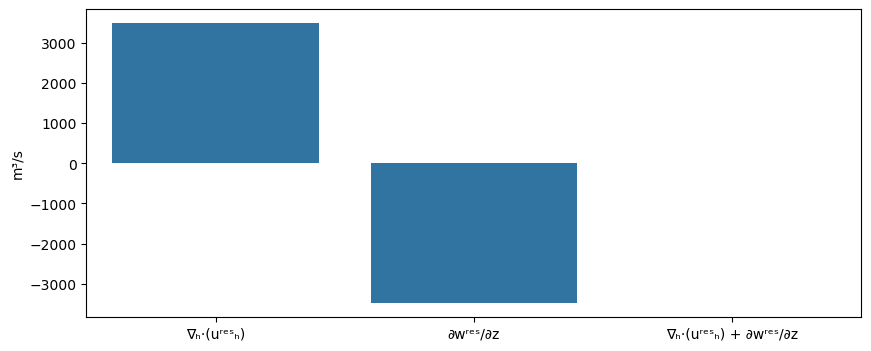

In [21]:
select_cell(x) = x[4, 20][110, 45]

vars = [select_cell(UVres_conv3D), 
        select_cell(Wres_conv3D)] 
push!(vars, sum(vars))
labels = ["∇ₕ⋅(uʳᵉˢₕ)", "∂wʳᵉˢ/∂z", "∇ₕ⋅(uʳᵉˢₕ) + ∂wʳᵉˢ/∂z"]

fig, ax = plt.subplots(figsize = (10, 4))
sns.barplot(x=labels, y=vars, ax = ax)
ax.set_ylabel("m³/s")
fig